# MediaPipe Hand Tracking for Robotics
MediaPipe uses a two-stage machine learning pipeline:
1. A **palm detector** that finds the bounding box of a hand.
2. A **hand landmark model** that predicts 21 3D keypoints inside that box.

### **Cell 1: Environment Setup**
Use a Python virtual environment so this notebook's packages stay isolated from the rest of your computer. From a terminal opened in this notebook's directory, run:

**macOS/Linux**
```bash
python3.10 -m venv .venv
source .venv/bin/activate
python -m pip install --upgrade pip ipykernel
python -m pip install -r requirements.txt
```

**Windows (PowerShell)**
```powershell
py -3.10 -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install --upgrade pip ipykernel
python -m pip install -r requirements.txt
```

In VS Code, click **Select Kernel** in the top-right, choose **Python Environments**, and select the `.venv` you just created. Restart the kernel if prompted, then run the package-install cell below. `%pip` installs into the notebook's currently selected kernel.

> **Already ran the install cell in base Python 3.10?** No big deal: stop here, create/select `.venv` using the steps above, restart the kernel, and run this cell again. The packages installed in the base environment will not interfere with the virtual environment. You usually do not need to uninstall them; doing so could affect another project that uses the base environment.

The next cell installs the current MediaPipe Tasks package and Matplotlib. MediaPipe supplies NumPy and OpenCV as dependencies. After installation or an upgrade, **restart the notebook kernel** before continuing so Python does not keep an older imported package in memory.

In [1]:
import sys
import mediapipe as mp

print(sys.executable)
print("MediaPipe:", mp.__version__)

c:\Users\Laksh\.venvs\hand-tracking\Scripts\python.exe
MediaPipe: 0.10.21


In [2]:
import sys
print(f"Installing into: {sys.executable}")
%pip install --upgrade "mediapipe==0.10.21" "matplotlib<4"

Installing into: c:\Users\Laksh\.venvs\hand-tracking\Scripts\python.exe
Note: you may need to restart the kernel to use updated packages.


### **Cell 2: Imports and Model Initialization**
Download Google's Hand Landmarker model once and initialize the current MediaPipe Tasks API. The model is cached in `~/.cache/mediapipe`, so later runs do not download it again. This notebook uses `IMAGE` mode because it processes one webcam snapshot; a continuous robotics node should use `VIDEO` or `LIVE_STREAM` mode.

In [5]:
from pathlib import Path
from urllib.request import urlretrieve

import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/hand_landmarker/"
    "hand_landmarker/float16/latest/hand_landmarker.task"
)
MODEL_PATH = Path.home() / ".cache" / "mediapipe" / "hand_landmarker.task"
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

if not MODEL_PATH.exists():
    print("Downloading the Hand Landmarker model...")
    urlretrieve(MODEL_URL, MODEL_PATH)

options = vision.HandLandmarkerOptions(
    base_options=python.BaseOptions(model_asset_path=str(MODEL_PATH)),
    running_mode=vision.RunningMode.IMAGE,
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)
landmarker = vision.HandLandmarker.create_from_options(options)
print(f"MediaPipe {mp.__version__}; model ready at {MODEL_PATH}")

MediaPipe 0.10.21; model ready at C:\Users\Laksh\.cache\mediapipe\hand_landmarker.task


### **Cell 3: Processing and Visualization**
In a real ROS node, this logic would live inside your `cv_bridge` image callback. Here, we simulate it by capturing a frame from the webcam.

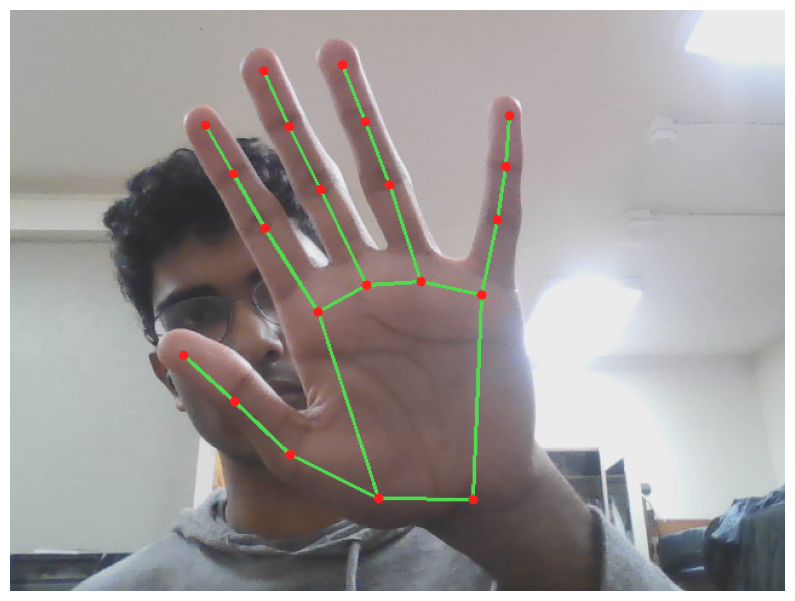

Detected 1 hand(s).


In [13]:
import time

# Open the default webcam using the macOS camera backend.
cap = cv2.VideoCapture(0)
frame = None

try:
    if not cap.isOpened():
        raise RuntimeError(
            "Could not open the webcam. Check macOS camera permissions "
            "and make sure another app is not using it."
        )

    # Give the camera time to start and let auto-exposure settle.
    time.sleep(1)

    # Discard startup frames, which may be black on macOS.
    for _ in range(30):
        ret, candidate = cap.read()

        if (
            ret
            and candidate is not None
            and candidate.size > 0
            and candidate.max() > 0
        ):
            frame = candidate

        time.sleep(0.03)

    if frame is None:
        raise RuntimeError(
            "The webcam opened but returned only empty or black frames."
        )

    # OpenCV supplies BGR pixels; MediaPipe expects RGB.
    image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=image_rgb,
    )

    results = landmarker.detect(mp_image)
    image_bgr = frame.copy()

    # Draw hand landmarks and connections.
    image_height, image_width, _ = image_bgr.shape

    for hand_landmarks in results.hand_landmarks:
        for connection in vision.HandLandmarksConnections.HAND_CONNECTIONS:
            start = hand_landmarks[connection.start]
            end = hand_landmarks[connection.end]

            start_px = (
                int(start.x * image_width),
                int(start.y * image_height),
            )
            end_px = (
                int(end.x * image_width),
                int(end.y * image_height),
            )

            cv2.line(
                image_bgr,
                start_px,
                end_px,
                (80, 220, 80),
                2,
            )

        for landmark in hand_landmarks:
            point = (
                int(landmark.x * image_width),
                int(landmark.y * image_height),
            )

            cv2.circle(
                image_bgr,
                point,
                4,
                (30, 30, 255),
                -1,
            )

    # Display the captured frame in the notebook.
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    if results.hand_landmarks:
        print(f"Detected {len(results.hand_landmarks)} hand(s).")
    else:
        print("Camera frame captured, but no hands were detected.")

finally:
    # Always release the camera, even if detection or plotting fails.
    cap.release()

### **Cell 4: Understanding Depth and Extracting Coordinates**
**Crucial note for robotics:** the Tasks API returns two coordinate sets:
* `results.hand_landmarks` contains normalized image coordinates. `x` and `y` are normalized by image width and height; `z` is relative depth with the wrist near the origin.
* `results.hand_world_landmarks` contains model-estimated 3D coordinates in meters, centered near the hand's geometric center.

World landmarks describe the hand's shape, but they are not automatically coordinates in your robot or camera frame. A ROS application still needs camera calibration and a frame transform; measured depth is preferable when accurate absolute positioning matters.

In [15]:
if 'results' in locals() and results.hand_landmarks:
    # Grab the first detected hand. Landmark 0 is the wrist; 8 is the index tip.
    first_hand = results.hand_landmarks[0]
    first_world_hand = results.hand_world_landmarks[0]
    
    print("--- RAW MEDIAPIPE COORDINATES ---")
    # Landmark 8 is the Index Finger Tip
    index_tip = first_hand[8]
    wrist = first_hand[0]
    
    print(f"Index Tip -> X: {index_tip.x:.4f}, Y: {index_tip.y:.4f}, Z: {index_tip.z:.4f}")
    print(f"Wrist     -> X: {wrist.x:.4f}, Y: {wrist.y:.4f}, Z: {wrist.z:.4f}\n")

    world_index_tip = first_world_hand[8]
    print("--- MODEL-ESTIMATED WORLD COORDINATES (METERS) ---")
    print(
        f"Index Tip -> X: {world_index_tip.x:.4f}, "
        f"Y: {world_index_tip.y:.4f}, Z: {world_index_tip.z:.4f}\n"
    )
    
    print("--- CONVERTING TO PIXEL COORDINATES ---")
    if 'frame' in locals():
        image_height, image_width, _ = frame.shape
        
        # De-normalize X and Y to get pixel coordinates
        pixel_x = int(index_tip.x * image_width)
        pixel_y = int(index_tip.y * image_height)
        print(f"Index Tip is at pixel: ({pixel_x}, {pixel_y})")
else:
    print("No hands detected in the frame. Run Cell 3 again to capture a frame.")

--- RAW MEDIAPIPE COORDINATES ---
Index Tip -> X: 0.2529, Y: 0.1999, Z: -0.1709
Wrist     -> X: 0.5970, Y: 0.8432, Z: 0.0000

--- MODEL-ESTIMATED WORLD COORDINATES (METERS) ---
Index Tip -> X: -0.0659, Y: -0.0528, Z: -0.0432

--- CONVERTING TO PIXEL COORDINATES ---
Index Tip is at pixel: (161, 95)


## Experiment: Reducing fingertip jitter

For this experiment, I focused on the index fingertip, which is landmark 8. The question was how to reduce small jumps in its detected position without making it respond too slowly when the hand moves.

I considered two approaches:

* A moving average, which averages a set number of recent positions.
* An exponential moving average (EMA), which blends each new position with the previous smoothed position.

I tested EMA with two settings, 0.2 and 0.7, using my saved webcam recordings. I compared the original and smoothed coordinates while moving my hand, then used a separate recording with my hand held still to measure the change in steadiness.

I also included a reset when tracking is lost, so the filter starts from the newly detected position when the hand returns.


In [9]:
import csv
from pathlib import Path

folder = Path.cwd()

recording_path = folder / "hand_landmarks_20260919_224511.csv"

with recording_path.open(newline="", encoding="utf-8") as file:
    rows = list(csv.DictReader(file))

# Each detected hand has 21 landmark rows per frame.
# Keep only landmark 8: the index fingertip.
fingertip_rows = [
    row for row in rows
    if row["tracked"].lower() == "true"
    and row["landmark_index"] == "8"
]

lost_rows = [
    row for row in rows
    if row["tracked"].lower() == "false"
]

print("Loaded:", recording_path.name)
print("Total CSV rows:", len(rows))
print("Index fingertip observations:", len(fingertip_rows))
print("Frames with no hand detected:", len(lost_rows))

Loaded: hand_landmarks_20260919_224511.csv
Total CSV rows: 12470
Index fingertip observations: 589
Frames with no hand detected: 101


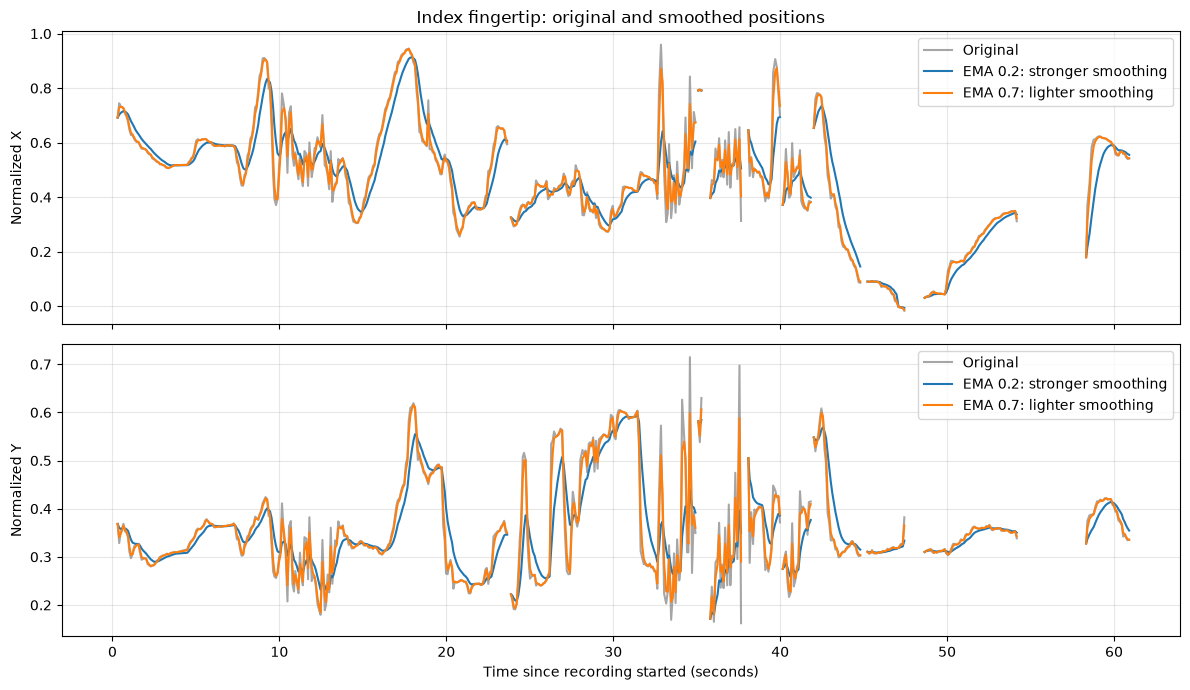

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Group the recorded rows by video frame.
frames = {}
for row in rows:
    frame_number = int(row["frame_index"])
    frames.setdefault(frame_number, []).append(row)

times = []
positions = []
labels = []

for frame_number in sorted(frames):
    frame_rows = frames[frame_number]
    times.append(float(frame_rows[0]["timestamp_ms"]) / 1000)

    tips = [
        row for row in frame_rows
        if row["tracked"].lower() == "true"
        and row["landmark_index"] == "8"
    ]

    # Use only frames containing exactly one detected hand.
    if len(tips) == 1:
        tip = tips[0]
        positions.append([
            float(tip["normalized_x"]),
            float(tip["normalized_y"]),
        ])
        labels.append(tip["handedness"])
    else:
        positions.append([np.nan, np.nan])
        labels.append(None)

times = np.array(times)
times -= times[0]
positions = np.array(positions)

def smooth_positions(alpha):
    output = np.full_like(positions, np.nan)
    previous = None
    previous_label = None

    for i, point in enumerate(positions):
        if not np.isfinite(point).all():
            # Forget the old position when tracking is unavailable.
            previous = None
            previous_label = None
            continue

        if previous is None or labels[i] != previous_label:
            previous = point.copy()
        else:
            previous = alpha * point + (1 - alpha) * previous

        output[i] = previous
        previous_label = labels[i]

    return output

strong_smoothing = smooth_positions(0.2)
light_smoothing = smooth_positions(0.7)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for axis, coordinate, name in zip(axes, [0, 1], ["X", "Y"]):
    axis.plot(times, positions[:, coordinate],
              color="gray", alpha=0.7, label="Original")
    axis.plot(times, strong_smoothing[:, coordinate],
              label="EMA 0.2: stronger smoothing")
    axis.plot(times, light_smoothing[:, coordinate],
              label="EMA 0.7: lighter smoothing")
    axis.set_ylabel(f"Normalized {name}")
    axis.grid(alpha=0.3)
    axis.legend()

axes[0].set_title("Index fingertip: original and smoothed positions")
axes[1].set_xlabel("Time since recording started (seconds)")
plt.tight_layout()
plt.show()

In [11]:
import csv
from pathlib import Path
import numpy as np

stationary_path = folder / "stationary_20260919_230543.csv"

with stationary_path.open(newline="", encoding="utf-8") as file:
    stationary_rows = list(csv.DictReader(file))

# Keep the index fingertip and the rows marking tracking loss.
samples = [
    row for row in stationary_rows
    if row["tracked"].lower() == "false"
    or row["landmark_index"] == "8"
]

start_time = float(samples[0]["timestamp_ms"]) / 1000
end_time = float(samples[-1]["timestamp_ms"]) / 1000

# Exclude the first and last 3 seconds to avoid setup/exit movement.
previous_raw = None
previous_frame = None
previous_label = None
previous_time = None
filtered = {0.2: None, 0.7: None}
changes = {"Original": [], "EMA 0.2": [], "EMA 0.7": []}

for row in samples:
    timestamp = float(row["timestamp_ms"]) / 1000
    frame_number = int(row["frame_index"])

    usable = (
        row["tracked"].lower() == "true"
        and start_time + 3 <= timestamp <= end_time - 3
    )

    if not usable:
        previous_raw = None
        for alpha in filtered:
            filtered[alpha] = None
        continue

    point = np.array([
        float(row["normalized_x"]),
        float(row["normalized_y"]),
    ])
    label = row["handedness"]

    continuous = (
        previous_raw is not None
        and frame_number == previous_frame + 1
        and label == previous_label
        and 0 < timestamp - previous_time <= 0.5
    )

    if continuous:
        changes["Original"].append(np.linalg.norm(point - previous_raw))

        for alpha in filtered:
            old_position = filtered[alpha]
            new_position = alpha * point + (1 - alpha) * old_position
            changes[f"EMA {alpha}"].append(
                np.linalg.norm(new_position - old_position)
            )
            filtered[alpha] = new_position
    else:
        for alpha in filtered:
            filtered[alpha] = point.copy()

    previous_raw = point
    previous_frame = frame_number
    previous_label = label
    previous_time = timestamp

print("Recording:", stationary_path.name)
print("Compared consecutive-frame pairs:", len(changes["Original"]))

if not changes["Original"]:
    print("Not enough continuous tracking in the selected interval.")
else:
    baseline = np.mean(changes["Original"])

    print("\nMean position change per frame (normalized image units):")
    for name, values in changes.items():
        mean_change = np.mean(values)
        reduction = (
            100 * (1 - mean_change / baseline)
            if baseline > 0 else float("nan")
        )
        print(
            f"{name}: {mean_change:.6f}"
            f" | reduction versus original: {reduction:.1f}%"
        )

Recording: stationary_20260919_230543.csv
Compared consecutive-frame pairs: 682

Mean position change per frame (normalized image units):
Original: 0.003281 | reduction versus original: 0.0%
EMA 0.2: 0.001597 | reduction versus original: 51.3%
EMA 0.7: 0.002717 | reduction versus original: 17.2%


## Results and conclusions

### Why I tested EMA

A moving average gives equal weight to the last N positions. Increasing N can reduce fluctuations, but it also keeps older positions in the average for longer.

EMA uses the current measurement and the previous smoothed position:

`smoothed = alpha * current + (1 - alpha) * previous_smoothed`

With alpha set to 0.2, the new measurement gets 20% of the weight. With alpha set to 0.7, it gets 70%. The smaller value smooths more, while the larger value responds more directly to new measurements.

I tested EMA because the calculation is simple and only needs the previous smoothed position.

### What I tested

I used two webcam recordings. In the first, I moved my hand slowly and quickly, moved it partly outside the frame, and briefly hid it. I plotted the index fingertip’s X and Y coordinates to compare the original movement with both EMA settings.

For the second recording, I rested my arm and tried to hold my hand still. I excluded the first and last three seconds to avoid including movement from getting ready or stopping the recording.

The stationary analysis compared 682 consecutive-frame pairs. It measured the distance between the fingertip positions in each pair, then averaged those distances. The filter reset when tracking was interrupted.

### Results

The distances below use normalized image coordinates, not meters.

| Method   | Average position change per frame | Reduction compared with original |
| -------- | --------------------------------: | -------------------------------: |
| Original |                          0.003281 |                               0% |
| EMA 0.2  |                          0.001597 |                            51.3% |
| EMA 0.7  |                          0.002717 |                            17.2% |

EMA 0.2 reduced changes between frames by 51.3% in the stationary test. EMA 0.7 reduced them by 17.2%.

The movement graphs show the other side of this result. EMA 0.2 softened the sharp changes more, but it also lagged behind the original signal. EMA 0.7 stayed closer to the original movement and smoothed less.

### What I learned

More smoothing comes at the cost of responsiveness. EMA 0.2 gave the steadier output in this test, but I would not choose it for robot control based on that number alone. The added delay would also matter.

EMA 0.7 kept more of the small fluctuations, but followed movement more closely. The choice would depend on how much delay and unwanted movement the application can tolerate.

### Limits of this experiment

I only used one stationary recording, and my hand was not perfectly still. The measured changes include both natural hand movement and variation in the tracking output. Reducing those changes does not prove that the position is more accurate.

I compared delay visually in the graphs rather than measuring it in milliseconds. The same alpha value can also produce different amounts of delay at different frame rates.

This code analyzes saved recordings. I have not connected the filter to ROS or used it to control the arm.

A useful next step would be to implement a moving average for comparison and measure delay with a repeatable movement.


### **Next Steps (the part where YOU guys do stuff!!)**
First, if Ethan does not go over handtracking demo with you, take a shot at 
running it with your webcam! See what it looks like to run it live in a video 
and observe how it collects data.

Now, the fun part! There are a LOT of questions that need to be arbitrated 
on the software side. These include, as examples:
- How does one reduce jitter? The positions are predictions made by the model 
at a given point in time on a given frame and are thus not inherently smoothed 
between frames; this is BAD if we are moving an end effector of an arm
based on this data.
- How does one turn 21 landmarks into a single point that the end effector will
moved bassed on? Different hand positions might lend to different answers if we 
do not well-define an approach.
- How to depth estimate? We do NOT own an RGB-D camera (one with fancy depth 
software). What challenges may this bring and how may we overcome them?
- We take this data; how does one interface it with the rest of the ROS 
ecosystem? How does one write the tf2 that will transmit this point data effectively?
- Doing ALL of this; how can we minimize latency in this system? Note right now
we are calling an API...

This list is not necessarily exhaustive; it's up to y'all to think like 
software designers and come up with these questions pre-emptively!

Your task is to take an open design question and explore it; find different 
approaches to how to tackle the design question and provide Ethan both a short 
documented explanation of this question and an attempt at implementing a 
contained approach (whether it be in a copy of this notebook, in the `hand_tracking_demo.py` 
file, or in an entirely separate file). Feel free to work in pairs or small groups!

Put all of this stuff into a directory titled with your first initial and last name (e.g. `egopez` for me!) in a git branch
titled `vha_onboarding_<FIRST_INITIAL><LASTNAME>` (e.g. `vha_onboarding_egopez`).
If multiple people in a group, append the names.